# Binary Classifier Basics

# Objectives

* Learn how to use *probabilistic* binary classifiers in sklearn
* * Call `fit` to train them on provided labeled dataset
* * Call `predict_proba` to get probabilistic predictions (will give you multiple columns, one per possible label)
* * * use `predict_proba(...)[:,1]` to get just the probabilities of the positive class
* * Call `predict` to get hard binary decisions

* See tradeoffs among two common classifiers
* * Logistic Regression
* * K Nearest Neighbors

# Outline
* [Part 1: Binary classification with Logistic Regression on 1-dim. toy example](#part1)
* [Part 2: Binary classification with K-NN on 1-dim. toy example](#part2)
* [Part 3: Confusion matrices and accuracy](#part3)
* [Part 4 (Bonus): Visualizing decision boundaries of Logistic Regression on 2-dim. features](#part4)
* [Part 5 (Bonus): Visualizing decision boundaries of K-NN on 2-dim. features](#part5)

We expect you'll get through the first 3 parts during this lab.

# Takeaways

* We need to carefully index the output of `predict_proba` to be sure we have the proba we are looking for
* Logistic Regression produces linear decision boundaries (as function of features)
* K-nearest neighbors produces piecewise constant decision boundaries (as function of features)


In [1]:
import numpy as np

In [2]:
import sklearn.linear_model
import sklearn.neighbors

In [4]:
# import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set_theme('notebook', font_scale=1.25, style='whitegrid')

# Setting up a simple classification task with 1-dim features

Let's think about a classification task where:

Each input is just scalar $x$ between -1 and +1.

If $x>0$, then $y$ has a 85\% chance of being 1 (and 15\% chance of being 0). If $x \leq 0$, then $y$ has a 85% chance of being 0 and 15% chance of being 1.

This noise makes our classification interesting. If we collected an enormous dataset, even the best possible model would still have an error rate of about ~15%.

### Make training set for 1-dim. toy example

In [5]:
# We generated this training set for you.

N = 12

x_N = np.asarray([
    -0.975, -0.825, -0.603, -0.378, -0.284, -0.102,
     0.169,  0.311,  0.431,  0.663,  0.795,  0.976])
x_N1 = x_N.reshape((N,1)) # need an (N,1) shaped array for later use with sklearn

y_N = np.asarray([0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1])

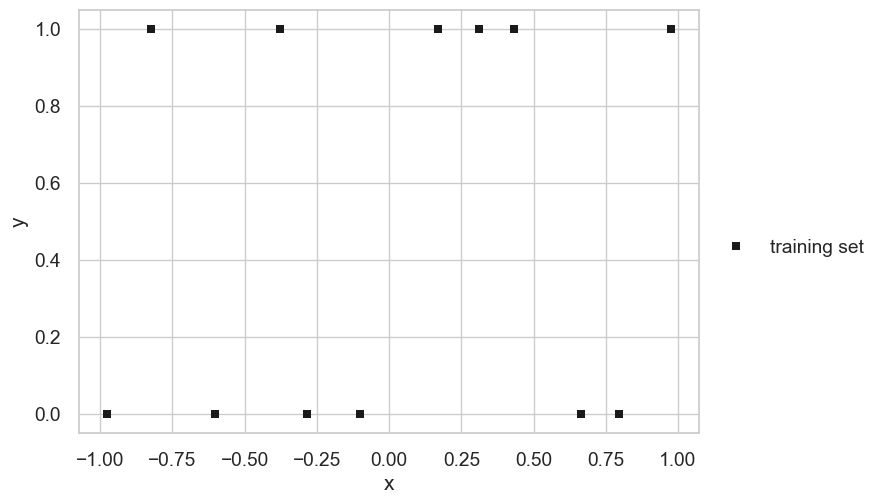

In [6]:
plt.plot(x_N, y_N, 'ks', label='training set');
plt.xlabel('x');
plt.ylabel('y');
plt.legend(bbox_to_anchor=(1.0, 0.5));

### Make validation set for 1-d toy example

The "true function" here makes y usually positive when x is positive, and y usually negative when x is negative. With probability of 15%, the y has opposite sign to x.

In [7]:
def make_dataset(n_examples=10, seed=101, flip_fraction=0.15):
    N = int(n_examples)
    prng = np.random.RandomState(seed)

    # Make x values between -1 and 1, roughly evenly spaced
    x_N = np.linspace(-1, 1, N) + 0.05 * prng.randn(N)

    # Make y values such that broadly, the true function says:
    # y_n = 1  if x_n > 0 
    # y_n = 0  otherwise
    y_N = np.asarray(x_N > 0, dtype=np.int32)

    # flip a small percentage of the values
    chosen_ids = prng.permutation(np.arange(N))[:int(np.floor(flip_fraction * N))]
    y_N[chosen_ids] = 1 - y_N[chosen_ids]
    return x_N.reshape((N,1)), y_N

In [8]:
M = 100
x_va_M1, y_va_M = make_dataset(n_examples=M, seed=201)

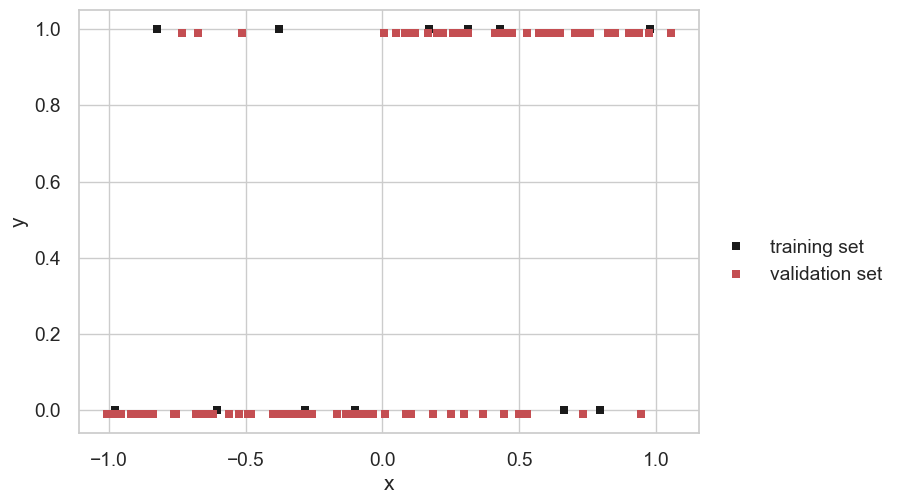

In [9]:
plt.plot(x_N, y_N, 'ks', label='training set');
plt.plot(x_va_M1, y_va_M - 0.01, 'rs', label='validation set'); # add small vertical offset so you can see

plt.xlabel('x');
plt.ylabel('y');
plt.legend(bbox_to_anchor=(1.0, 0.5));

<a id="part1"></a>

# Part 1: Train a logistic regression model for F=1 data

Here, we'll fit a Logistic Regression probabilistic classifier to the above 1-dim. feature dataset.

Remember the training objective for Logistic Regression for scalar $w$ and scalar $b$ is:

$$
w^*, b^* \gets \mathrm{arg\,min}_{w \in \mathbb{R}, b \in \mathbb{R}} ~~ \sum_{n=1}^N \text{bce}( y_n, \sigma(w x + b) ) + \frac{1}{C} w^2
$$

where that second term is like an L2 penalty.

sklearn prefers using the strength $\frac{1}{C}$ for historical reasons. So just know that $C > 0$ works inversely as $\alpha$ did for RidgeRegression.

* Larger $C$ means weaker penalty 
* Smaller $C$ (closer to zero) means larger penalty on weight magnitudes, favoring $w$ close to zero

In [10]:
# The argument l1_ratio=0 gives us l2 regularization. If we were to set l1_ratio=1, we'd get l1 regularization. 
# values in the middle would correspond to adding *both* penalties in the specified ratio.

lr = sklearn.linear_model.LogisticRegression(C=10000.0, l1_ratio=0);

In [11]:
lr.fit(x_N1, y_N)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

Just like linear regression, logistic regression has two learnable parameters for 1-dim features:

* a weight coefficient "coef_"
* an intercept coefficient "intercept_"

Peek at the learned weights and intercept

In [12]:
lr.coef_

array([[0.5293339]])

In [13]:
lr.intercept_

array([-0.0081371])

### Make probabilistic predictions with predict_proba

Remember, `predict_proba()` returns the probabilities of ALL possible labels: 0 and 1

There will be two columns, one for each label.

The first column is for the class corresponding to binary label 0.
The second column is for the class corresponding to binary label 1.

In [14]:
yproba_N2 = lr.predict_proba(x_N1)
print("yproba_N2")
print("Shape: " + str(yproba_N2.shape))
print(yproba_N2)

yproba_N2
Shape: (12, 2)
[[0.62813814 0.37186186]
 [0.60941112 0.39058888]
 [0.58110847 0.41889153]
 [0.55186905 0.44813095]
 [0.53953429 0.46046571]
 [0.5155273  0.4844727 ]
 [0.47968112 0.52031888]
 [0.4609582  0.5390418 ]
 [0.44521933 0.55478067]
 [0.41512675 0.58487325]
 [0.39826888 0.60173112]
 [0.37554692 0.62445308]]


To get only the probabilities for the positive class (y=1), grab the *second* column (the column with *index 1*)

In [15]:
yproba1_N = lr.predict_proba(x_N1)[:,1]

print("yproba1_N")
print("Shape: " + str(yproba1_N.shape))
print(yproba1_N)

yproba1_N
Shape: (12,)
[0.37186186 0.39058888 0.41889153 0.44813095 0.46046571 0.4844727
 0.52031888 0.5390418  0.55478067 0.58487325 0.60173112 0.62445308]


### Exercise 1a: How would you calculate the probability of the "negative" class (label y=0)?

Remember, if there are only two possible events, $A$ and $B$, we can always say:

$p(A) + p(B) = 1$

In [16]:
yproba0_N = np.ones(N) - yproba1_N  # compute yproba0_N from yproba1_N
yproba0_N

array([0.62813814, 0.60941112, 0.58110847, 0.55186905, 0.53953429,
       0.5155273 , 0.47968112, 0.4609582 , 0.44521933, 0.41512675,
       0.39826888, 0.37554692])

### Make binary predictions with `predict`

Calling the function `lr.predict(...)` produces a binary value, either 0 or 1, for each of the N input examples

In [17]:
yhat_N = lr.predict(x_N1)

print("yhat_N")
print("Shape: " + str(yhat_N.shape))
print(yhat_N)

yhat_N
Shape: (12,)
[0 0 0 0 0 0 1 1 1 1 1 1]


### Exercise 1b: Can you reproduce these "binary" predictions by thresholding yproba1 at 0.5?

By default, sklearn uses a threshold of 0.5.

Any probability of the positive event equal to or above 0.5 will be predicted as positive integer 1.
Otherwise, a 0 integer value will be predicted

In [20]:
# TODO edit code below so its predictions match the result of lr.predict() above
# You can change a numpy binary array to an integer array using
# `np.asarray(bin_arr, dtype=np.int32)`
# If correct, your output should exactly equal [0 0 0 0 0 0 1 1 1 1 1 1]

my_yhat_N = yproba1_N > 0.5 #  Use threshold of 0.5 and cast to integer
my_yhat_N = my_yhat_N.astype(int)

print(my_yhat_N)

[0 0 0 0 0 0 1 1 1 1 1 1]


### Plot: predicted probabilities vs. feature value

We can see that the predicted probabilities from Logistic Regression are *smooth* functions of input features.


In [21]:
# Create dense grid of L input examples from -1.5 to 1.5
# so we can better understand the learned predictions
L = 101
dense_x_L1 = np.linspace(-1.5, 1.5, L).reshape((L,1))
yproba1_dense_L = lr.predict_proba(dense_x_L1)[:,1]

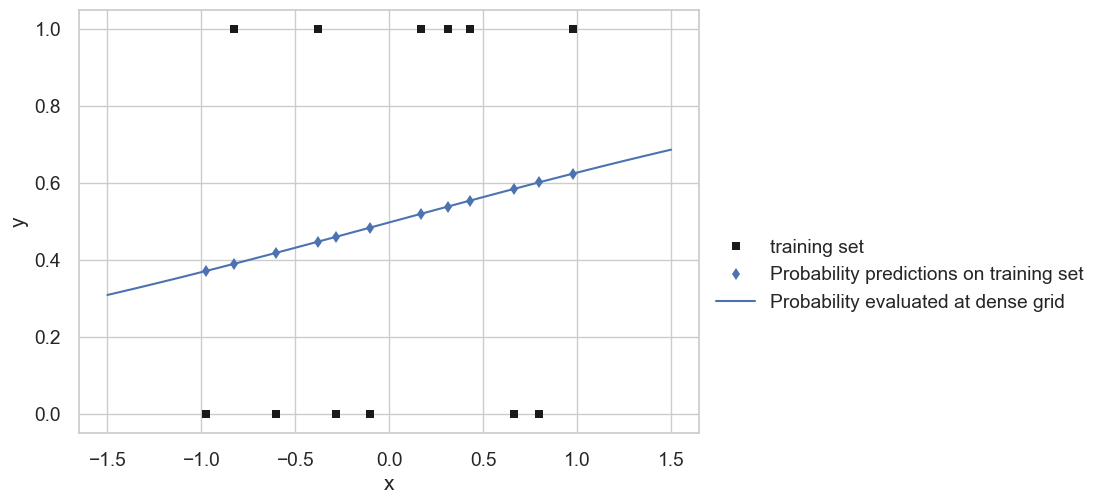

In [22]:
plt.plot(x_N, y_N, 'ks', label='training set');
plt.plot(x_N, yproba1_N, 'bd', label='Probability predictions on training set');
plt.plot(dense_x_L1, yproba1_dense_L, 'b-', label='Probability evaluated at dense grid')

plt.xlabel('x');
plt.ylabel('y');
plt.legend(bbox_to_anchor=(1.0, 0.5));

<a id="part2"></a>

# Part 2: Train a k-nearest neighbors model for F=1 data

Here, we'll fit a K Nearest probabilistic classifier to the above 1-dim. feature dataset.

In [23]:
# We'll use K = 3 neighbors for now. You could select it like any hyperparameter on validation data.

knn = sklearn.neighbors.KNeighborsClassifier(n_neighbors=3)

In [24]:
knn.fit(x_N1, y_N)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [25]:
knn_yproba1_N = knn.predict_proba(x_N1)[:,1]
print("knn_yproba1_N")
print("Shape: " + str(knn_yproba1_N.shape))
print(knn_yproba1_N)

knn_yproba1_N
Shape: (12,)
[0.33333333 0.33333333 0.66666667 0.33333333 0.33333333 0.33333333
 1.         1.         0.66666667 0.33333333 0.33333333 0.33333333]


### Plot predicted probabilities vs feature value

We'll again use the same dense grid of L inputs to understand the predicted probability function.

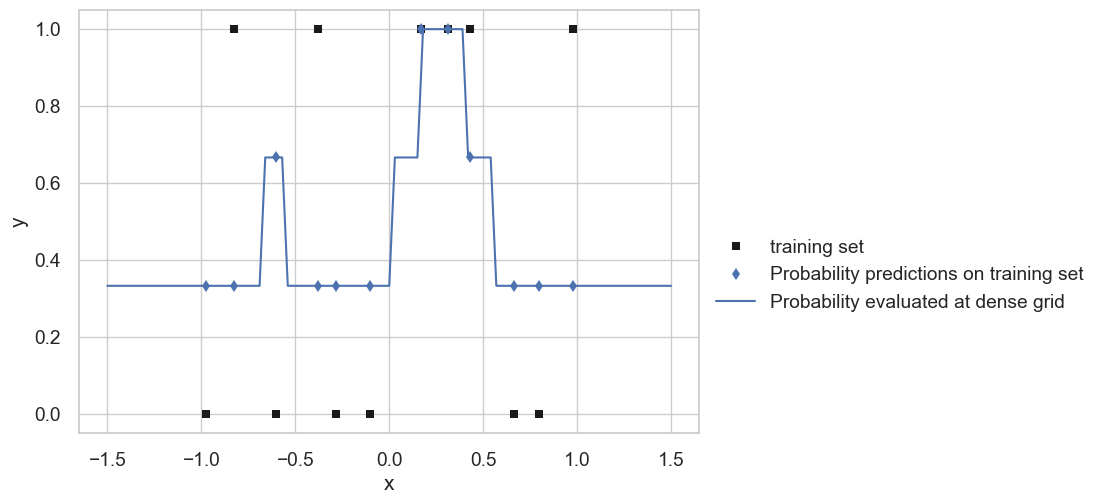

In [26]:
plt.plot(x_N, y_N, 'ks', label='training set');
plt.plot(x_N, knn_yproba1_N, 'bd', label='Probability predictions on training set');
plt.plot(dense_x_L1, knn.predict_proba(dense_x_L1)[:,1], 'b-', label='Probability evaluated at dense grid')

plt.xlabel('x');
plt.ylabel('y');
plt.legend(bbox_to_anchor=(1.0, 0.5));

### Discussion 2a: What is happening at x = 0.05? What 3 neighbors are used to make the prediction?

piecewise jump, 1 neighbor at y = 0 and 2 neighbors at y = 1 give a probability of y_hat being 1 of 0.66. 

### Discussion 2b: Why does the above plot have "piecewise constant" predicted probabilities?

"sudden" changes in what the three closest neighbors to the subsequent point are

<a id="part3"></a>

# Part 3: Computing confusion matrices on validation set

Remember, the order of the cells in a confusion matrix is like this diagram:

    | -- | -- |
    | TN | FP |
    | FN | TP |
    | -- | -- |

In [27]:
lr_yhat_va_M = lr.predict(x_va_M1)
knn_yhat_va_M = knn.predict(x_va_M1)

In [28]:
print("LR confusion:")
sklearn.metrics.confusion_matrix(y_va_M, lr_yhat_va_M)

LR confusion:


array([[47, 11],
       [ 4, 38]])

In [29]:
print("3-NN confusion:")
sklearn.metrics.confusion_matrix(y_va_M, knn_yhat_va_M)

3-NN confusion:


array([[43, 15],
       [24, 18]])

### Exercise 3a: What is the accuracy of the LR classifier on validation set?

In [32]:
# compute using data from the printed confusion matrices above
lr_conf = sklearn.metrics.confusion_matrix(y_va_M, lr_yhat_va_M)
acc = (lr_conf[0, 0] + lr_conf[1, 1]) / np.sum(lr_conf)
print(acc)

0.85


### Exercise 3b: What is the accuracy of the KNN classifier on validation set?

In [33]:
# TODO compute using data from the printed confusion matrices above

knn_conf = sklearn.metrics.confusion_matrix(y_va_M, knn_yhat_va_M)
acc_knn = (knn_conf[0, 0] + knn_conf[1, 1]) / np.sum(knn_conf)
print(acc_knn)

0.61


### Discussion 3c: Which classifier has better accuracy on the validation set? Does this match what you'd think from the pictures visualizing the predicted probability functions above?

Logistic regression. Yes, in the predicted probability functions, the KNN predicted probabilities drop to under 0.5 for all positive x values greater than ~0.5.

# Setup for Parts 4 - 5

### Define simple dataset of points in 2D space

Don't worry about the details of this setup.
Just try to understand the plots below.

In [34]:
def create_2d_dataset(N=100, noise_stddev=0.1, random_state=0):
    random_state = np.random.RandomState(int(random_state))

    mA_2 = np.asarray([1, 0])
    covA_22 = np.square(noise_stddev) * np.eye(2)
    
    mB_2 = np.asarray([0, 0])
    covB_22 = np.square(noise_stddev) * np.eye(2)

    mC_2 = np.asarray([0, 1])
    covC_22 = np.square(noise_stddev) * np.eye(2)

    # Draw data from 3 "Gaussian" blobs
    xA_N2 = random_state.multivariate_normal(mA_2, covA_22, size=N)
    xB_N2 = random_state.multivariate_normal(mB_2, covB_22, size=N)
    xC_N2 = random_state.multivariate_normal(mC_2, covC_22, size=N)

    x_N2 = np.vstack([xA_N2, xB_N2, xC_N2])
    y_N = np.hstack([np.ones(xA_N2.shape[0]), np.zeros(xB_N2.shape[0]), np.ones(xC_N2.shape[0])])
    
    return x_N2, y_N

## Create the dataset with 100 points for each binary class

In [35]:
x_N2, y_N = create_2d_dataset(N=100, noise_stddev=0.3)

## Define function to plot data as scatterpoints in 2d

In [36]:
def plot_pretty_data_colored_by_labels(x_N2, y_N):
    plt.plot(x_N2[y_N==0,0], x_N2[y_N==0,1], color='r', marker='x', linestyle='', markersize=5, mew=2, label='y=0');
    plt.plot(x_N2[y_N==1,0], x_N2[y_N==1,1], color='b', marker='+', linestyle='', markersize=8, mew=2, label='y=1');

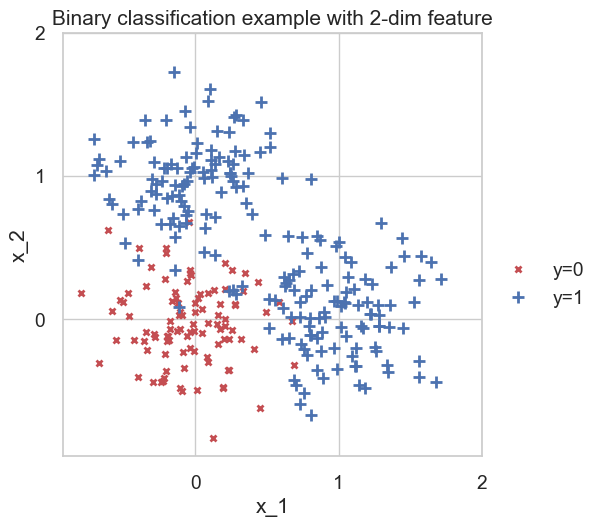

In [37]:
plot_pretty_data_colored_by_labels(x_N2, y_N);
plt.legend(bbox_to_anchor=(1.0, 0.5));
plt.xlabel('x_1');
plt.ylabel('x_2');
plt.gca().set_aspect(1.0);
plt.xticks([0, 1, 2]);
plt.yticks([0, 1, 2]);
plt.title("Binary classification example with 2-dim feature");

### Define function to make pretty plots of predicted probability color fields

You don't need to understand this in detail. Just a utility function.

In [38]:
def plot_pretty_probabilities_for_clf(
        clf,
        do_show_colorbar=False,
        x1_ticks=np.asarray([0, 2, 4]),
        x2_ticks=np.asarray([0, 2, 4]),
        c_levels=np.linspace(0, 1, 100),
        c_ticks=np.asarray([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
        x1_grid=np.linspace(-1, 2.3, 100),
        x2_grid=np.linspace(-1, 2.3, 100)):
    cur_ax = plt.gca()
    
    G = x1_grid.size
    H = x2_grid.size
    
    # Get regular grid of G x H points, where each point is an (x1, x2) location
    x1_GH, x2_GH = np.meshgrid(x1_grid, x2_grid)
    
    # Combine the x1 and x2 values into one array
    # Flattened into M = G x H rows
    # Each row of x_M2 is a 2D vector [x_m1, x_m2]
    x_M2 = np.hstack([x1_GH.flatten()[:,np.newaxis], x2_GH.flatten()[:,np.newaxis]])
    
    # Predict proba for each point in the flattened grid
    yproba1_M = clf.predict_proba(x_M2)[:,1]
    
    # Reshape the M probas into the GxH 2D field
    yproba1_GH = np.reshape(yproba1_M, x1_GH.shape)
    
    cmap = plt.cm.RdYlBu
    my_contourf_h = plt.contourf(x1_GH, x2_GH, yproba1_GH, levels=c_levels, vmin=0, vmax=1.0, cmap=cmap)
    
    plt.xticks(x1_ticks, x1_ticks);
    plt.yticks(x2_ticks, x2_ticks);
    
    if do_show_colorbar:
        left, bottom, width, height = plt.gca().get_position().bounds
        cax = plt.gcf().add_axes([left+1.1*width, bottom, 0.03, height])
        plt.colorbar(my_contourf_h, orientation='vertical', cax=cax, ticks=c_ticks);
        plt.sca(cur_ax);

### Define function to visualize hard decisions made as threshold

You don't need to understand this in detail. Just a utility function you'll use below.

In [39]:
def plot_pretty_decision_boundaries_for_clf(
        clf,
        threshold=0.5,
        do_show_colorbar=False,
        x1_ticks=np.asarray([0, 2, 4]),
        x2_ticks=np.asarray([0, 2, 4]),
        c_levels=np.linspace(0, 1, 100),
        c_ticks=np.asarray([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
        x1_grid=np.linspace(-1, 2.3, 100),
        x2_grid=np.linspace(-1, 2.3, 100)):
    cur_ax = plt.gca()
    
    G = x1_grid.size
    H = x2_grid.size
    
    # Get regular grid of G x H points, where each point is an (x1, x2) location
    x1_GH, x2_GH = np.meshgrid(x1_grid, x2_grid)
    
    # Combine the x1 and x2 values into one array
    # Flattened into M = G x H rows
    # Each row of x_M2 is a 2D vector [x_m1, x_m2]
    x_M2 = np.hstack([x1_GH.flatten()[:,np.newaxis], x2_GH.flatten()[:,np.newaxis]])
    
    # Predict proba for each point in the flattened grid
    yproba1_M = clf.predict_proba(x_M2)[:,1]
    yhat_M = yproba1_M >= threshold
    
    # Reshape the M probas into the GxH 2D field
    yhat_GH = np.reshape(yhat_M, x1_GH.shape)
    
    cmap = plt.cm.RdYlBu
    my_contourf_h = plt.contourf(x1_GH, x2_GH, yhat_GH, levels=c_levels, vmin=0, vmax=1.0, cmap=cmap)
    
    plt.xticks(x1_ticks, x1_ticks);
    plt.yticks(x2_ticks, x2_ticks);
    
    if do_show_colorbar:
        left, bottom, width, height = plt.gca().get_position().bounds
        cax = plt.gcf().add_axes([left+1.1*width, bottom, 0.03, height])
        plt.colorbar(my_contourf_h, orientation='vertical', cax=cax, ticks=c_ticks);
        plt.sca(cur_ax);

<a id="part5"></a>

<a id="part4"></a>

# Part 4: Visualization of KNN predictions as we vary K

### Figure:  KNN predicted proba (colors) over 2D plane of x1, x2 

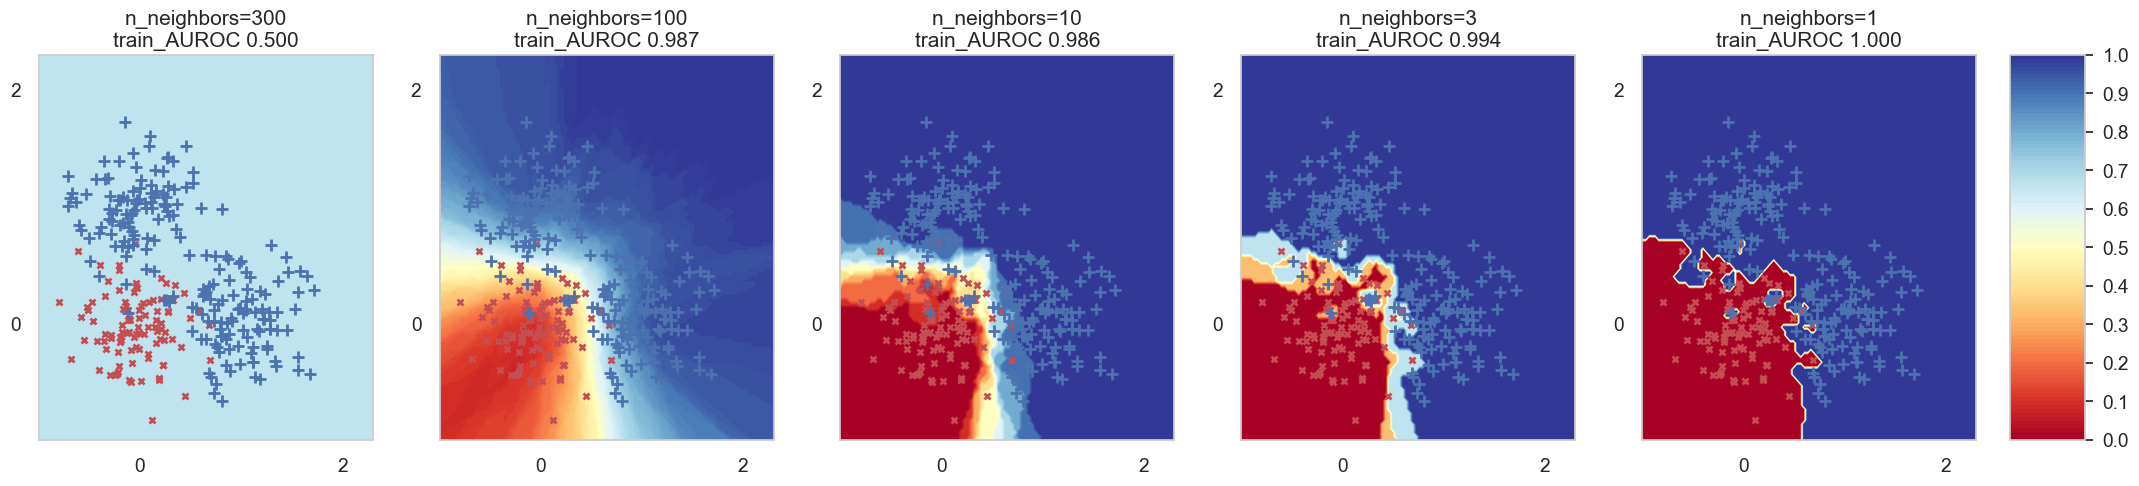

In [40]:
n_neighbors_grid = [y_N.size, 100, 10, 3,  1]
ncols = len(n_neighbors_grid)

fig_h, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 5))

is_last = False
for ii, n_neighbors in enumerate(n_neighbors_grid):
    if ii == ncols - 1:
        is_last = True
    plt.sca(axes[ii])
    clf = sklearn.neighbors.KNeighborsClassifier(n_neighbors=n_neighbors, algorithm='brute')
    clf.fit(x_N2, y_N)
    auroc = sklearn.metrics.roc_auc_score(y_N, clf.predict_proba(x_N2)[:,1])

    plot_pretty_probabilities_for_clf(clf, do_show_colorbar=is_last);
    plot_pretty_data_colored_by_labels(x_N2, y_N);
    
    plt.title("n_neighbors=%d\ntrain_AUROC %.3f" % (n_neighbors, auroc))

## KNN: hard binary decisions (colors) over 2D plane of (x1, x2)

Using Threshold: 0.5

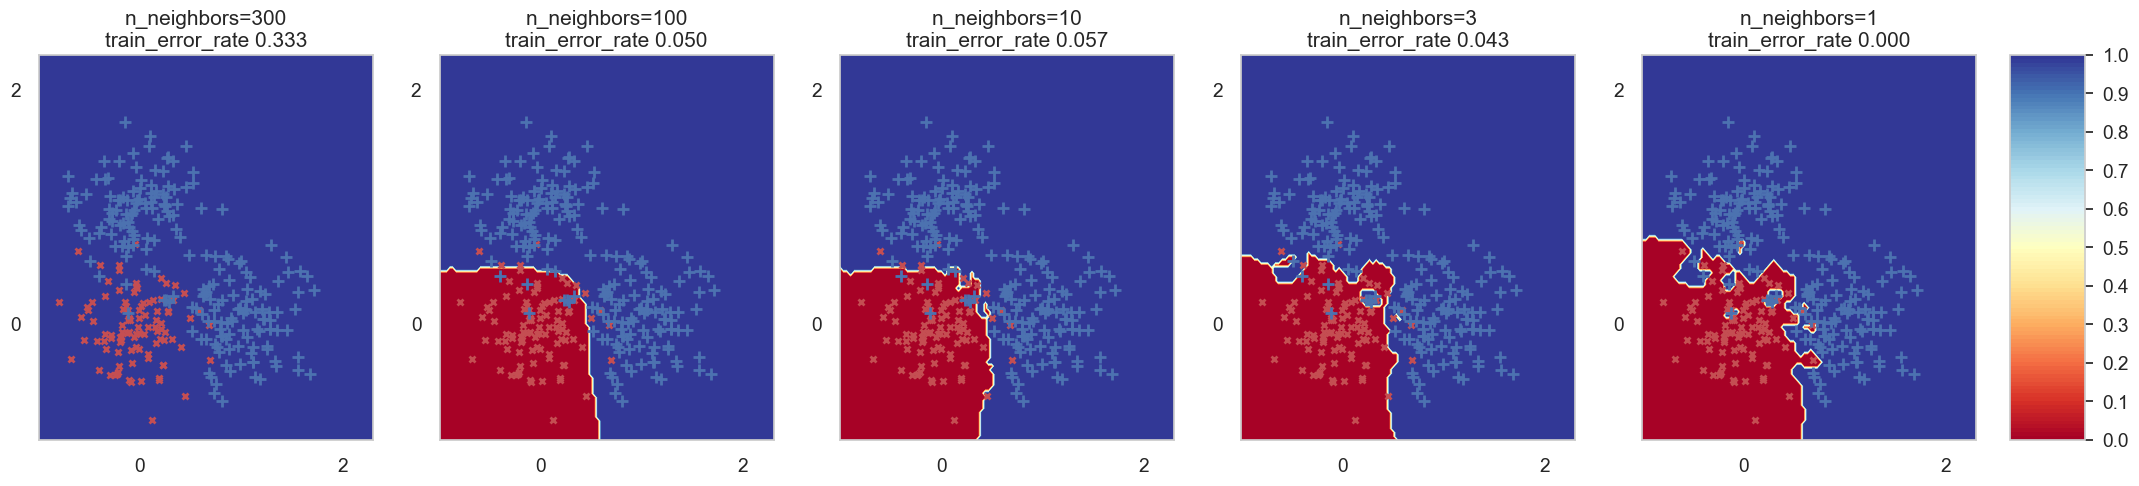

In [41]:
n_neighbors_grid = [y_N.size, 100, 10, 3,  1]
ncols = len(n_neighbors_grid)

fig_h, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 5))

is_last = False
for ii, n_neighbors in enumerate(n_neighbors_grid):
    if ii == ncols - 1:
        is_last = True
    plt.sca(axes[ii])
    clf = sklearn.neighbors.KNeighborsClassifier(n_neighbors=n_neighbors, algorithm='brute')
    clf.fit(x_N2, y_N)
    err_rate = np.mean(np.logical_xor(y_N, clf.predict(x_N2)))
    
    plot_pretty_decision_boundaries_for_clf(clf, do_show_colorbar=is_last);
    plot_pretty_data_colored_by_labels(x_N2, y_N);
    
    plt.title("n_neighbors=%d\ntrain_error_rate %.3f" % (n_neighbors, err_rate))

<a id="part6"></a>

### Discussion 4a: Why does the KNN classifier get zero training error on the training set? Would we expect this on the validation set?

When K=1 and we want to predict for a training set point, the classifier finds the data point itself with distance 0 as its closest single neighbor. So, the predicted label is just based on itself's true label, which always matches when computing for accuracy. Hence, why at K=1 we see training error as 0.

We wouldn't expect this on the validation set, as they would be different points then those in the training set, and cannot query themselves as their own nearest neighbors. We expect this model to not generalize as well as the e.g. n_neighbors=3 or 10 models.

### Discussion 4b: How could you select the number of neighbors to use for this classifier?

Choose the K that has the lowest error on the validation set. 

<a id="part5"></a>

# Part 5: Visualization of Logistic Regression predictions as we vary C

Remember, C controls the *strength* of the L2 penalty on weight parameters.

* Large C means almost no penalty.
* Small C means all weights are close to zero.

C =  0.0001 Learned weights + intercept
[0.00350085 0.00359415 0.69089817]
C =   0.01 Learned weights + intercept
[0.30417482 0.31712202 0.5030436 ]
C =      1 Learned weights + intercept
[ 3.69899517  4.09474074 -1.13523683]
C =  1e+02 Learned weights + intercept
[ 6.3519369   7.08534503 -2.22042321]
C =  1e+06 Learned weights + intercept
[ 6.44640774  7.19137113 -2.25808008]


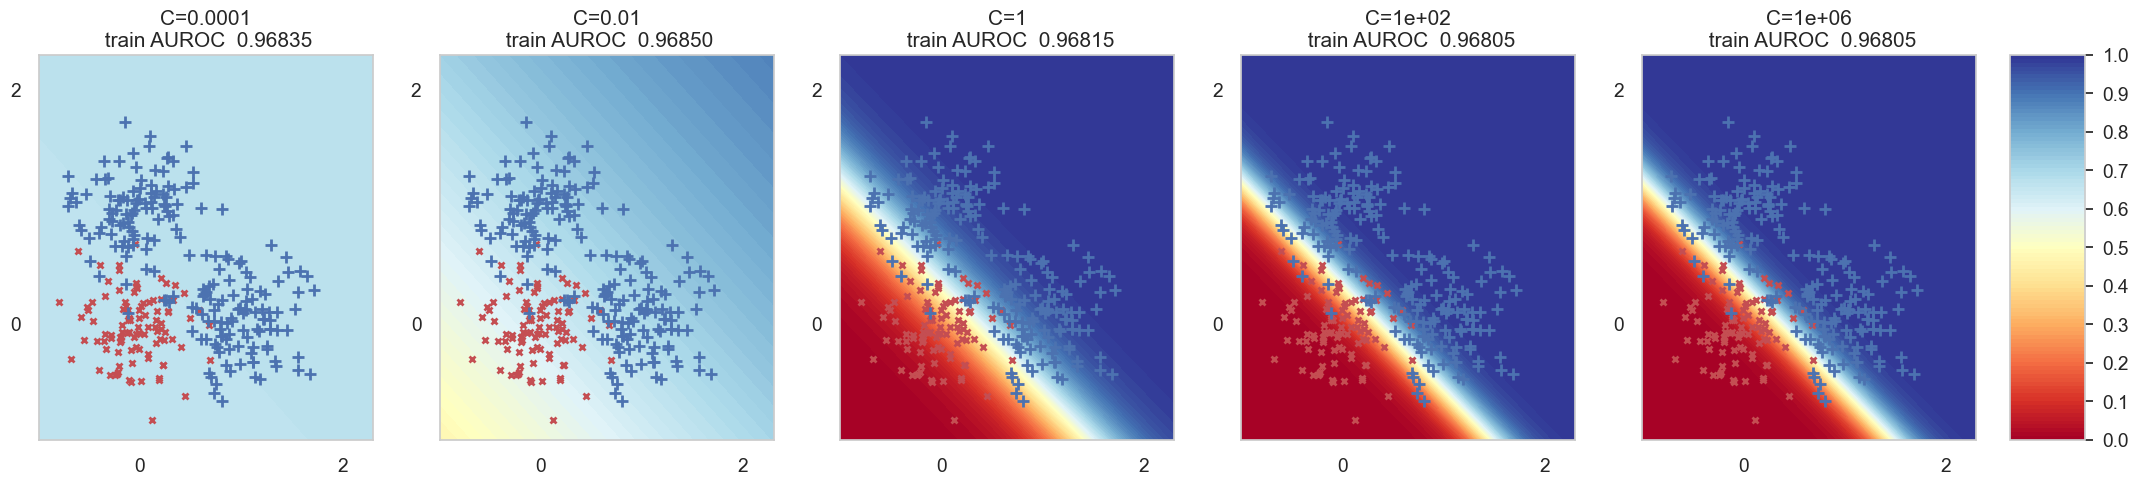

In [42]:
C_grid = np.asarray([0.0001, 0.01, 1, 100, 1000000])
ncols = len(C_grid)

fig_h, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 5))

is_last = False
for ii, C in enumerate(C_grid):
    if ii == ncols - 1:
        is_last = True
    plt.sca(axes[ii])
    clf = sklearn.linear_model.LogisticRegression(C=C)
    clf.fit(x_N2, y_N)
    auroc = sklearn.metrics.roc_auc_score(y_N, clf.predict_proba(x_N2)[:,1])

    plot_pretty_probabilities_for_clf(clf, do_show_colorbar=is_last);
    plot_pretty_data_colored_by_labels(x_N2, y_N);
    
    plt.title("C=%.2g\n train AUROC % .5f" % (C, auroc))
    
    print("C = % 6.2g Learned weights + intercept" % C)
    print(np.hstack([clf.coef_.flatten(), np.atleast_1d(clf.intercept_)]))

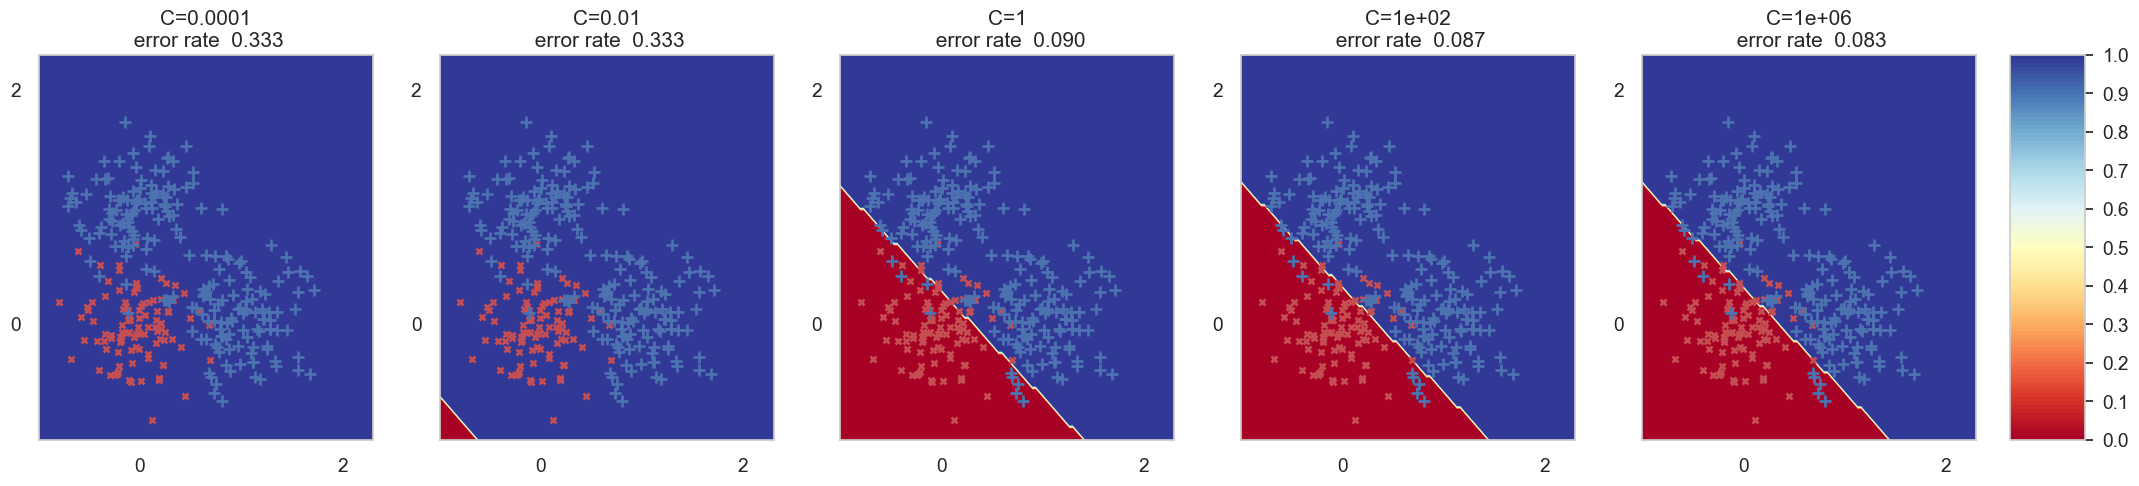

In [43]:
C_grid = np.asarray([0.0001, 0.01, 1, 100, 1000000])
ncols = len(C_grid)

fig_h, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(5 * ncols, 5))

is_last = False
for ii, C in enumerate(C_grid):
    if ii == ncols - 1:
        is_last = True
    plt.sca(axes[ii])
    clf = sklearn.linear_model.LogisticRegression(C=C)
    clf.fit(x_N2, y_N)    
    err_rate = np.mean(np.logical_xor(y_N, clf.predict(x_N2)))
    
    plot_pretty_decision_boundaries_for_clf(clf, do_show_colorbar=is_last);
    plot_pretty_data_colored_by_labels(x_N2, y_N);
    
    plt.title("C=%.2g\n error rate % .3f" % (C, err_rate))
    

### Challenge Exercise 5a: Why does the decision boundary look like a line? Can you justify why it is linear with math?

Remember:

$$
p( y_n = 1 | x_n) = \sigma( w^T x_n + b )
$$

The decision boundary is the set of points for which $\sigma(w^Tx_n+b) = 0.5$ (or equals $\tau$ if you set a different threshold). In fact, $\sigma(0)=0.5$, so this is the same as the set of points for which $w^Tx_n+b=0$, which is a linear function. Thus the decision boundary is a line!

Even if we had set a different threshold, we would end up with the set of points for which $w^Tx_n+b=\sigma^{-1}(\tau)$, where $\sigma^{-1}$ is the inverse of the sigmoid function (because sigmoid is one-to-one, its inverse exists). This is always a line in $x_n$!

### Challenge Exercise 5b: Given the learned weights and intercept below, can you find the equation for the decision line?

In [ ]:
clf.coef_

array([[6.44640774, 7.19137113]])

In [ ]:
clf.intercept_

array([-2.25808008])

From the previous answer, we have $6.45 \cdot x_1+ 7.19 \cdot x_2 - 2.26 = 0$, which we can rearrange to get
$$x_2 = -\frac{6.45}{7.19} \cdot x_1 + \frac{2.26}{7.19} = -0.9 x_1 +0.31$$